# Transmon qubit

This notebook revisits the scqubits `demo_transmon` flow using the features currently available in `ScQubitsMimic.jl`.

Implemented here:
- programmatic Transmon creation and parameter mutation
- eigenenergies and eigensystems in the charge basis
- energy spectra vs `n_g` and `E_J`
- charge-basis wavefunctions and phase-basis wavefunctions reconstructed from charge-basis eigenvectors
- charge-dispersion trends vs `E_J`
- matrix elements and matrix elements vs parameter values
- validation against a `Circuit`-derived transmon

Not currently provided as built-in library APIs:
- GUI-based object creation
- dedicated `plot_phi_wavefunction`, `plot_dispersion_vs_paramvals`, and `plot_matelem_vs_paramvals` convenience methods

The missing pieces are implemented below with small notebook-local helper functions built on the exported low-level APIs.


In [1]:
using ScQubitsMimic
using CairoMakie

_scqubitsmimic_example_dir = normpath(joinpath(dirname(pathof(ScQubitsMimic)), "..", "examples"))
if !isdefined(Main, :ScQubitsMimicExampleMakie)
    include(joinpath(_scqubitsmimic_example_dir, "makie_fontsetup.jl"))
end
ScQubitsMimicExampleMakie.setup_makie_font!()


"Apple SD Gothic Neo"

In [2]:
transmon_summary(t::Transmon) = (
    EJ=t.EJ,
    EC=t.EC,
    ng=t.ng,
    ncut=t.ncut,
    truncated_dim=t.truncated_dim,
    EJ_over_EC=t.EJ / t.EC,
    hilbertdim=hilbertdim(t),
)

const _MODE_FUNC_DICT = Dict{Symbol, Function}(
    :abs_sqr => abs2,
    :abs => abs,
    :real => real,
    :imag => imag,
)

const _NAME_REPLACEMENTS = Dict{Symbol, String}(
    :ng => "n_g",
    :ng1 => "n_g1",
    :ng2 => "n_g2",
    :EJ => "E_J",
    :EJ1 => "E_J1",
    :EJ2 => "E_J2",
    :EJ3 => "E_J3",
    :EC => "E_C",
    :EL => "E_L",
    :flux => "Φ_ext/Φ₀",
)

function _normalize_mode(mode::Union{Symbol, AbstractString})
    mode_sym = mode isa Symbol ? mode : Symbol(mode)
    haskey(_MODE_FUNC_DICT, mode_sym) || error("Unsupported mode: $(mode)")
    return mode_sym
end

function _process_which(which, max_index::Int)
    indices = if which isa Integer
        which == -1 ? collect(0:max_index - 1) : [Int(which)]
    else
        [Int(idx) for idx in which]
    end
    isempty(indices) && error("which must not be empty")
    all(0 .<= indices .< max_index) || error("which must be between 0 and $(max_index - 1)")
    return indices
end

_recast_name(param_name::Symbol) = get(_NAME_REPLACEMENTS, param_name, string(param_name))
_recast_name(param_name::AbstractString) = _recast_name(Symbol(param_name))

function _mode_label(mode::Symbol, base::String)
    mode == :abs_sqr && return "|" * base * "|^2"
    mode == :abs && return "|" * base * "|"
    mode == :real && return "Re " * base
    return "Im " * base
end

function _phase_ylabel(mode::Symbol; subtract_ground::Bool=false)
    energy_label = subtract_ground ? "energy - E₀ [GHz]" : "energy [GHz]"
    return _mode_label(mode, "ψ_j(ϕ)") * ", " * energy_label
end

function _phi_values(; phi_grid=nothing, phi_range=(-π, π), pt_count::Int=151)
    if phi_grid !== nothing
        return collect(phi_grid)
    end
    φrange = collect(phi_range)
    if length(φrange) == 2
        return collect(range(φrange[1], φrange[2], length=pt_count))
    elseif length(φrange) == 3
        return collect(range(φrange[1], φrange[2], length=Int(φrange[3])))
    end
    error("phi_range must have length 2 or 3")
end

function _resolve_esys(sys::Transmon, esys, states0::AbstractVector{<:Integer})
    required = max(maximum(states0) + 1, 3)
    if esys === nothing
        return eigensys(sys; evals_count=required)
    end
    evals, evecs = esys
    length(evals) >= required || error("esys must contain at least $(required) eigenstates")
    return evals, evecs
end

function _standardize_sign(amplitudes::AbstractVector)
    halfway = length(amplitudes) ÷ 2
    halfway == 0 && return collect(amplitudes)
    sign_factor = sign(sum(amplitudes[1:halfway]))
    return iszero(sign_factor) ? collect(amplitudes) : sign_factor .* amplitudes
end

function _set_wavefunction_scaling(wavefunctions, potential_vals)
    Y_RANGE_THRESHOLD_FRACTION = 1 / 12
    FILLING_FRACTION = 0.9
    MAX_AMPLITUDE_FRACTION = 1 / 7
    PRECISION_THRESHOLD = 1e-6

    energies = [wf.energy for wf in wavefunctions]
    e_max = maximum(energies)
    e_min = minimum(energies)
    e_range = e_max - e_min
    y_min = minimum(potential_vals)
    y_max = e_max + 0.3 * e_range
    y_range = y_max - y_min

    amp_mins = [minimum(wf.amplitudes) for wf in wavefunctions]
    amp_maxs = [maximum(wf.amplitudes) for wf in wavefunctions]
    max_amplitude_range = maximum(amp_maxs .- amp_mins)

    max_amplitude_range < PRECISION_THRESHOLD && return 1.0

    scale_factor = y_range * MAX_AMPLITUDE_FRACTION / max_amplitude_range
    amp_mins .*= scale_factor
    amp_maxs .*= scale_factor

    length(wavefunctions) == 1 && return scale_factor

    amplitude_fillings = [abs(amp_maxs[i]) + abs(amp_mins[i + 1]) for i in 1:length(wavefunctions)-1]
    energy_spacings = [energies[i + 1] - energies[i] for i in 1:length(wavefunctions)-1]

    for idx in eachindex(energy_spacings)
        energy_gap = energy_spacings[idx]
        amplitude_filling = amplitude_fillings[idx]
        if energy_gap > y_range * Y_RANGE_THRESHOLD_FRACTION &&
           amplitude_filling > energy_gap * FILLING_FRACTION
            reduction = energy_gap * FILLING_FRACTION / amplitude_filling
            scale_factor *= reduction
            amp_mins .*= reduction
            amp_maxs .*= reduction
            amplitude_fillings .*= reduction
        end
    end

    return scale_factor
end

function numberbasis_wavefunction_data(sys::Transmon; esys=nothing, which::Int=0)
    states0 = _process_which(which, sys.truncated_dim)
    evals, evecs = _resolve_esys(sys, esys, states0)
    state0 = only(states0)
    state = state0 + 1
    return (
        basis_labels=collect(-sys.ncut:sys.ncut),
        amplitudes=evecs[:, state],
        energy=evals[state],
    )
end

function phase_wavefunction_data(sys::Transmon, which::Int;
                                 esys=nothing,
                                 phi_grid=nothing,
                                 phi_range=(-π, π),
                                 pt_count::Int=151)
    states0 = _process_which(which, sys.truncated_dim)
    evals, evecs = _resolve_esys(sys, esys, states0)
    state0 = only(states0)
    state = state0 + 1
    charges = collect(-sys.ncut:sys.ncut)
    phis = _phi_values(phi_grid=phi_grid, phi_range=phi_range, pt_count=pt_count)
    coeffs = evecs[:, state]
    phase_factor = (1im)^state0 / sqrt(2π)
    psi_phi = ComplexF64[
        phase_factor * sum(coeffs .* exp.(1im .* ϕ .* charges))
        for ϕ in phis
    ]
    return (
        basis_labels=phis,
        amplitudes=psi_phi,
        energy=evals[state],
    )
end

function plot_n_wavefunction(sys::Transmon, which::Int=0;
                             esys=nothing,
                             mode::Union{Symbol, AbstractString}=:real,
                             nrange=(-5, 6))
    mode_sym = _normalize_mode(mode)
    n_wavefunc = numberbasis_wavefunction_data(sys; esys=esys, which=which)
    y_vals = _MODE_FUNC_DICT[mode_sym].(n_wavefunc.amplitudes)

    fig = Figure(size=(680, 380))
    ax = Axis(fig[1, 1],
              xlabel="n",
              ylabel=_mode_label(mode_sym, "ψ_j(n)"))
    barplot!(ax, n_wavefunc.basis_labels, y_vals;
             width=0.75,
             color=:steelblue,
             strokewidth=0)
    ax.xticks = (n_wavefunc.basis_labels, string.(n_wavefunc.basis_labels))
    xlims!(ax, nrange...)
    return fig
end

plot_n_wavefunction(sys::Transmon; which::Int=0, kwargs...) = plot_n_wavefunction(sys, which; kwargs...)

function plot_evals_vs_paramvals_scqubits(sweep::ParameterSweep;
                                          subtract_ground::Bool=false,
                                          evals_count::Union{Nothing, Int}=nothing)
    pvals = sweep.param_vals
    evals = copy(sweep.spectrum.eigenvalues)
    n_evals = isnothing(evals_count) ? size(evals, 2) : min(evals_count, size(evals, 2))

    if subtract_ground
        evals .-= evals[:, 1]
    end

    fig = Figure(size=(680, 380))
    ax = Axis(fig[1, 1],
              xlabel=_recast_name(sweep.param_name),
              ylabel=subtract_ground ? "energy - E₀ [GHz]" : "energy [GHz]")

    for level in 1:n_evals
        lines!(ax, pvals, evals[:, level])
    end
    return fig
end

function plot_wavefunction(sys::Transmon,
                           which::Union{Int, Tuple, AbstractVector{<:Integer}}=0;
                           mode::Union{Symbol, AbstractString}=:real,
                           esys=nothing,
                           phi_grid=nothing,
                           phi_range=(-π, π),
                           pt_count::Int=151,
                           scaling=nothing,
                           subtract_ground::Bool=false)
    mode_sym = _normalize_mode(mode)
    states0 = _process_which(which, sys.truncated_dim)
    evals, evecs = _resolve_esys(sys, esys, states0)
    phis = _phi_values(phi_grid=phi_grid, phi_range=phi_range, pt_count=pt_count)
    potential_vals = -sys.EJ .* cos.(phis)
    ground_energy = subtract_ground ? evals[1] : 0.0

    wavefunctions = []
    for state0 in states0
        wf = phase_wavefunction_data(sys, state0; esys=(evals, evecs), phi_grid=phis)
        amplitudes = _MODE_FUNC_DICT[mode_sym].(_standardize_sign(wf.amplitudes))
        push!(wavefunctions,
              (basis_labels=wf.basis_labels,
               amplitudes=Float64.(amplitudes),
               energy=wf.energy - ground_energy))
    end

    potential_shifted = potential_vals .- ground_energy
    scale_factor = isnothing(scaling) ? _set_wavefunction_scaling(wavefunctions, potential_shifted) : Float64(scaling)

    fig = Figure(size=(700, 420))
    ax = Axis(fig[1, 1],
              xlabel="ϕ",
              ylabel=_phase_ylabel(mode_sym; subtract_ground=subtract_ground))

    lines!(ax, phis, potential_shifted; color=:gray60, linewidth=2)

    palette = [:dodgerblue, :tomato, :darkgreen, :darkorange, :mediumpurple]
    for (idx, wf) in enumerate(wavefunctions)
        color = palette[1 + mod(idx - 1, length(palette))]
        y_vals = wf.energy .+ scale_factor .* wf.amplitudes
        baseline = fill(wf.energy, length(phis))
        band!(ax, phis, baseline, y_vals; color=(color, 0.22))
        lines!(ax, phis, y_vals; color=color, linewidth=2)
    end

    y_min = minimum(potential_shifted)
    y_max = maximum(wf.energy for wf in wavefunctions)
    y_range = y_max - y_min
    y_max += 0.3 * y_range
    y_min -= 0.1 * y_range
    ylims!(ax, y_min, y_max)
    return fig
end

function plot_phi_wavefunction(sys::Transmon, which::Union{Int, Tuple, AbstractVector{<:Integer}}=0; kwargs...)
    return plot_wavefunction(sys, which; kwargs...)
end

function plot_phase_wavefunctions(sys::Transmon, which::Union{Int, Tuple, AbstractVector{<:Integer}}=0; kwargs...)
    return plot_phi_wavefunction(sys, which; kwargs...)
end

plot_wavefunction(sys::Transmon; which=0, kwargs...) = plot_wavefunction(sys, which; kwargs...)

plot_phi_wavefunction(sys::Transmon; which=0, kwargs...) = plot_phi_wavefunction(sys, which; kwargs...)

plot_phase_wavefunctions(sys::Transmon; which=0, kwargs...) = plot_phase_wavefunctions(sys, which; kwargs...)

function plot_charge_dispersion_overlay(configs;
                                        ng_vals=range(-2.0, 2.0, length=220),
                                        evals_count::Int=6,
                                        subtract_ground::Bool=true)
    fig = Figure(size=(760, 420))
    ax = Axis(fig[1, 1],
              xlabel=_recast_name(:ng),
              ylabel=subtract_ground ? "energy - E₀ [GHz]" : "energy [GHz]")
    colors = [:dodgerblue, :tomato, :darkgreen, :mediumpurple]

    for (cfg_idx, (label, sys, linestyle)) in enumerate(configs)
        sweep = get_spectrum_vs_paramvals(sys, :ng, collect(ng_vals); evals_count=evals_count)
        vals = subtract_ground ? (sweep.eigenvalues .- sweep.eigenvalues[:, 1]) : sweep.eigenvalues
        color = colors[1 + mod(cfg_idx - 1, length(colors))]
        for level in 1:evals_count
            lines!(ax, sweep.param_vals, vals[:, level],
                   color=color,
                   linestyle=linestyle,
                   linewidth=level <= 2 ? 2.5 : 1.5,
                   alpha=0.85)
        end
        lines!(ax, [NaN], [NaN], color=color, linestyle=linestyle, linewidth=2.5, label=label)
    end

    axislegend(ax, position=:rb)
    return fig
end

function _transition_label(pair::Tuple{Int, Int})
    i, j = pair
    return string(i) * string(j)
end

function _normalize_transition_pairs(transitions)
    if transitions isa Tuple{Int, Int}
        return [(Int(transitions[1]), Int(transitions[2]))]
    end
    return [(Int(pair[1]), Int(pair[2])) for pair in transitions]
end

function _normalize_level_list(levels)
    levels isa Integer && return [Int(levels)]
    return [Int(level) for level in levels]
end

function _transmon_dispersion_data_scqubits(sys::Transmon,
                                            dispersion_name::Union{Symbol, AbstractString},
                                            param_name::Union{Symbol, AbstractString},
                                            param_vals;
                                            ref_param=nothing,
                                            transitions=((0, 1),),
                                            levels=nothing)
    dispersion_sym = dispersion_name isa Symbol ? dispersion_name : Symbol(dispersion_name)
    param_sym = param_name isa Symbol ? param_name : Symbol(param_name)
    dispersion_sym == :ng || error("Only ng dispersion is implemented in this notebook helper")

    param_vals_vec = collect(float.(param_vals))
    previous_dispersion = getproperty(sys, dispersion_sym)
    previous_param = getproperty(sys, param_sym)

    transition_pairs0 = _normalize_transition_pairs(transitions)
    levels0 = isnothing(levels) ? nothing : _normalize_level_list(levels)
    max_level0 = isnothing(levels0) ? maximum(Iterators.flatten(transition_pairs0)) : maximum(levels0)
    evals_count = max(max_level0 + 1, 3)

    spec_0 = nothing
    spec_05 = nothing
    try
        setproperty!(sys, dispersion_sym, 0.0)
        spec_0 = get_spectrum_vs_paramvals(sys, param_sym, param_vals_vec; evals_count=evals_count)
        setproperty!(sys, dispersion_sym, 0.5)
        spec_05 = get_spectrum_vs_paramvals(sys, param_sym, param_vals_vec; evals_count=evals_count)
    finally
        setproperty!(sys, dispersion_sym, previous_dispersion)
        setproperty!(sys, param_sym, previous_param)
    end

    x_vals = copy(param_vals_vec)
    x_label = string(param_sym)
    if !isnothing(ref_param)
        ref_sym = ref_param isa Symbol ? ref_param : Symbol(ref_param)
        ref_value = getproperty(sys, ref_sym)
        x_vals ./= ref_value
        x_label = string(param_sym) * "/" * string(ref_sym)
    end

    if !isnothing(levels0)
        data = hcat([
            abs.(spec_0.eigenvalues[:, level0 + 1] .- spec_05.eigenvalues[:, level0 + 1])
            for level0 in levels0
        ]...)
        labels = string.(levels0)
    else
        data = hcat([
            begin
                i0, j0 = pair0
                ω0 = abs.(spec_0.eigenvalues[:, j0 + 1] .- spec_0.eigenvalues[:, i0 + 1])
                ω05 = abs.(spec_05.eigenvalues[:, j0 + 1] .- spec_05.eigenvalues[:, i0 + 1])
                max.(ω0, ω05) .- min.(ω0, ω05)
            end
            for pair0 in transition_pairs0
        ]...)
        labels = [_transition_label(pair0) for pair0 in transition_pairs0]
    end

    return (
        x_vals=x_vals,
        x_label=x_label,
        y_vals=data,
        labels=labels,
        spec_0=spec_0,
        spec_05=spec_05,
    )
end

function plot_dispersion_vs_paramvals_scqubits(sys::Transmon,
                                               dispersion_name::Union{Symbol, AbstractString},
                                               param_name::Union{Symbol, AbstractString},
                                               param_vals;
                                               ref_param=nothing,
                                               transitions=((0, 1),),
                                               levels=nothing)
    data = _transmon_dispersion_data_scqubits(
        sys,
        dispersion_name,
        param_name,
        param_vals;
        ref_param=ref_param,
        transitions=transitions,
        levels=levels,
    )

    fig = Figure(size=(680, 380))
    ax = Axis(fig[1, 1],
              xlabel=data.x_label,
              ylabel="energy dispersion [GHz]",
              yscale=log10)

    for (idx, label) in enumerate(data.labels)
        lines!(ax, data.x_vals, data.y_vals[:, idx], label=label)
    end

    axislegend(ax, position=:rb)
    return fig
end

function plot_matelems_vs_paramvals(sys::ScQubitsMimic.AbstractQuantumSystem,
                                    op_builder::Function,
                                    param_name::Symbol,
                                    param_vals;
                                    pairs=[(1, 2), (1, 3), (2, 3), (1, 4)],
                                    mode::Union{Symbol, AbstractString}=:abs)
    mode_sym = _normalize_mode(mode)
    original = get_param(sys, param_name)
    max_eval = maximum(collect(Iterators.flatten(pairs)))
    traces = Dict{Tuple{Int, Int}, Vector{Float64}}(pair => Float64[] for pair in pairs)

    for val in param_vals
        set_param!(sys, param_name, Float64(val))
        op = op_builder(sys)
        table = matrixelement_table(sys, op; evals_count=max_eval)
        for pair in pairs
            i, j = pair
            elem = table[i, j]
            value = _MODE_FUNC_DICT[mode_sym](elem)
            push!(traces[pair], Float64(value))
        end
    end

    set_param!(sys, param_name, original)

    fig = Figure(size=(760, 420))
    ax = Axis(fig[1, 1],
              xlabel=_recast_name(param_name),
              ylabel="matrix element",
              title="Selected matrix elements vs $(_recast_name(param_name))")
    for pair in pairs
        i, j = pair
        lines!(ax, collect(param_vals), traces[pair], label="⟨$(i-1)|O|$(j-1)⟩")
    end
    axislegend(ax, position=:rt)
    return fig
end


plot_matelems_vs_paramvals (generic function with 1 method)

## 1. Programmatic creation

`ScQubitsMimic.jl` does not currently provide the GUI-style `Transmon.create()` workflow from scqubits, so we start with direct construction.


In [3]:
tmon = Transmon(EJ=15.0, EC=0.2, ng=0.0, ncut=15, truncated_dim=12)
transmon_summary(tmon)


(EJ = 15.0, EC = 0.2, ng = 0.0, ncut = 15, truncated_dim = 12, EJ_over_EC = 75.0, hilbertdim = 31)

## 2. Displaying and modifying parameters

The Transmon type is mutable, so the usual scqubits pattern of adjusting `EJ`, `EC`, or `ng` interactively maps directly to field updates.


In [4]:
tmon_demo = deepcopy(tmon)
tmon_demo.EJ = 15.0
tmon_demo.ng = 0.125
tmon_demo.EC = 0.2
transmon_summary(tmon_demo)


(EJ = 15.0, EC = 0.2, ng = 0.125, ncut = 15, truncated_dim = 12, EJ_over_EC = 75.0, hilbertdim = 31)

## 3. Computing eigenenergies and eigenstates

`eigenvals` returns eigenenergies only, while `eigensys` returns both eigenenergies and the corresponding charge-basis eigenvectors.


In [5]:
evals, evecs = eigensys(tmon; evals_count=12)

ω01 = evals[2] - evals[1]
ω12 = evals[3] - evals[2]
α = ω12 - ω01
ω01_approx = sqrt(8 * tmon.EJ * tmon.EC) - tmon.EC

(
    first_12_evals_GHz=round.(evals, digits=6),
    ω01_GHz=round(ω01, digits=6),
    ω12_GHz=round(ω12, digits=6),
    anharmonicity_GHz=round(α, digits=6),
    expected_minus_EC_GHz=round(-tmon.EC, digits=6),
    transmon_approx_GHz=round(ω01_approx, digits=6),
    approx_error_percent=round(abs(ω01 - ω01_approx) / ω01 * 100, digits=3),
    eigvec_matrix_size=size(evecs),
)


(first_12_evals_GHz = [-12.6016, -7.911819, -3.444852, 0.778915, 4.729596, 8.381409, 11.504219, 14.837341, 15.858732, 21.481474, 21.520865, 29.80684], ω01_GHz = 4.689781, ω12_GHz = 4.466966, anharmonicity_GHz = -0.222815, expected_minus_EC_GHz = -0.2, transmon_approx_GHz = 4.698979, approx_error_percent = 0.196, eigvec_matrix_size = (31, 12))

## 4. Energy levels vs offset charge `n_g`

The original scqubits example uses a very small `EJ` first so the charge dispersion is easy to see, and then compares it against a more transmon-like regime with larger `EJ/EC`. For an overlay between different transmons, we subtract each system's ground-state energy so the comparison focuses on physically relevant level spacings rather than arbitrary absolute offsets.


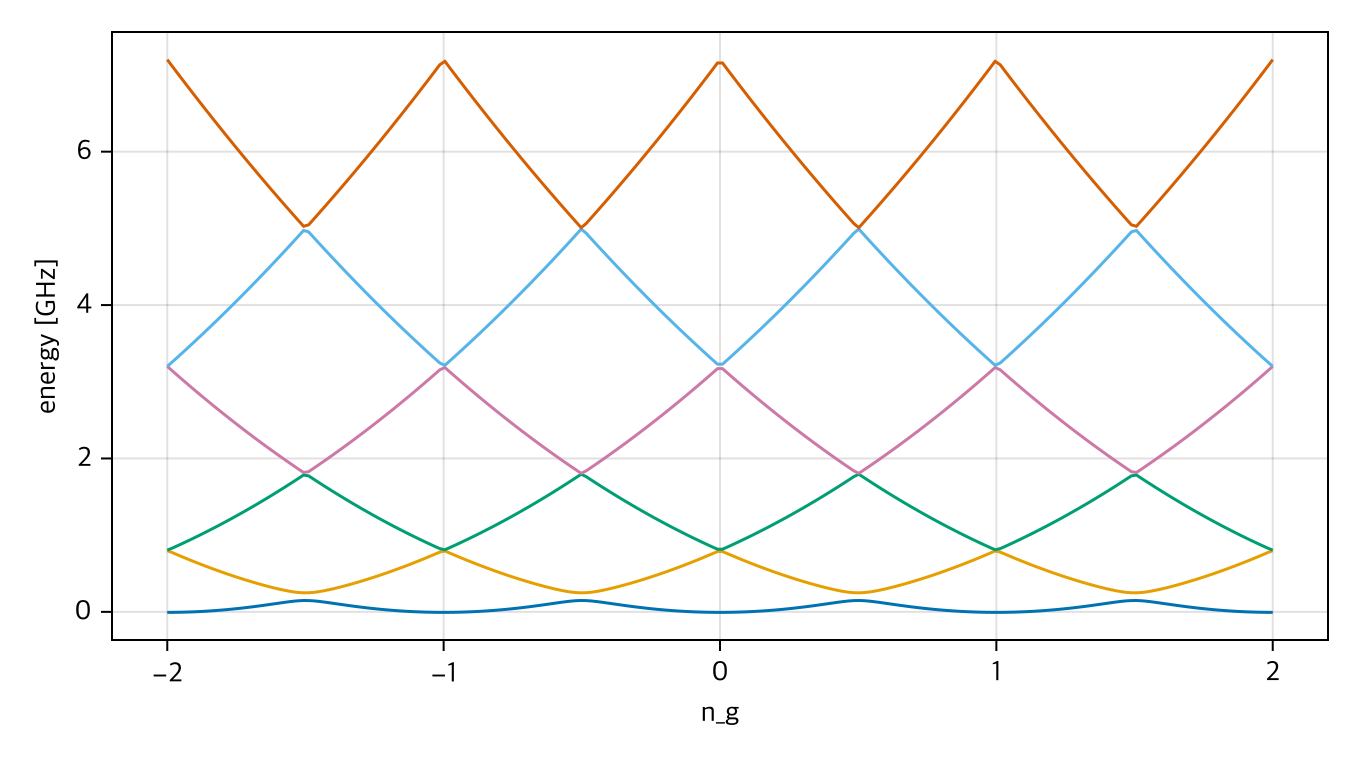

In [6]:
tmon_lowEJ = Transmon(EJ=0.1, EC=tmon.EC, ng=0.0, ncut=tmon.ncut, truncated_dim=6)
ng_sweep_low = ParameterSweep(tmon_lowEJ, :ng, range(-2.0, 2.0, length=220); evals_count=6)
plot_evals_vs_paramvals_scqubits(ng_sweep_low; subtract_ground=false, evals_count=6)


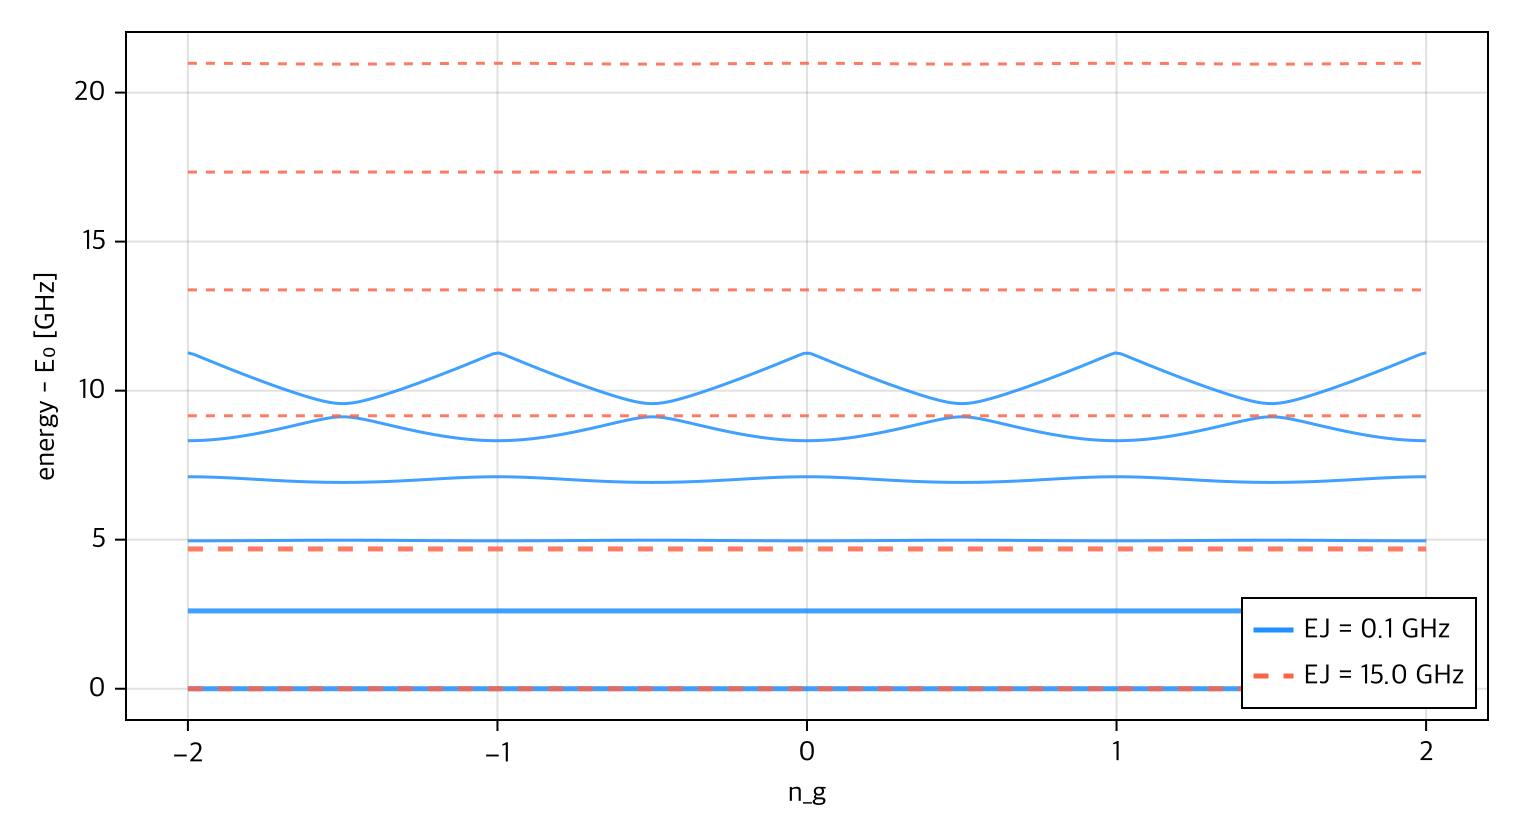

In [7]:
plot_charge_dispersion_overlay([
    ("EJ = 0.1 GHz", Transmon(EJ=5.0, EC=tmon.EC, ng=0.0, ncut=tmon.ncut, truncated_dim=6), :solid),
    ("EJ = 15.0 GHz", Transmon(EJ=15.0, EC=tmon.EC, ng=0.0, ncut=tmon.ncut, truncated_dim=6), :dash),
]; ng_vals=range(-2.0, 2.0, length=220), evals_count=6)


In [8]:
ng_probe = get_spectrum_vs_paramvals(tmon, :ng, collect(range(0.0, 0.5, length=101)); evals_count=2)
w01_probe = ng_probe.eigenvalues[:, 2] .- ng_probe.eigenvalues[:, 1]

(
    ω01_at_ng0_GHz=round(w01_probe[1], digits=8),
    ω01_at_ng0_5_GHz=round(w01_probe[end], digits=8),
    charge_dispersion_MHz=round((maximum(w01_probe) - minimum(w01_probe)) * 1000, digits=6),
)


(ω01_at_ng0_GHz = 4.68978109, ω01_at_ng0_5_GHz = 4.68978094, charge_dispersion_MHz = 0.000152)

## 5. Energy levels vs `EJ`

Sweeping `EJ` is built into the current codebase via `ParameterSweep` and `plot_evals_vs_paramvals`.


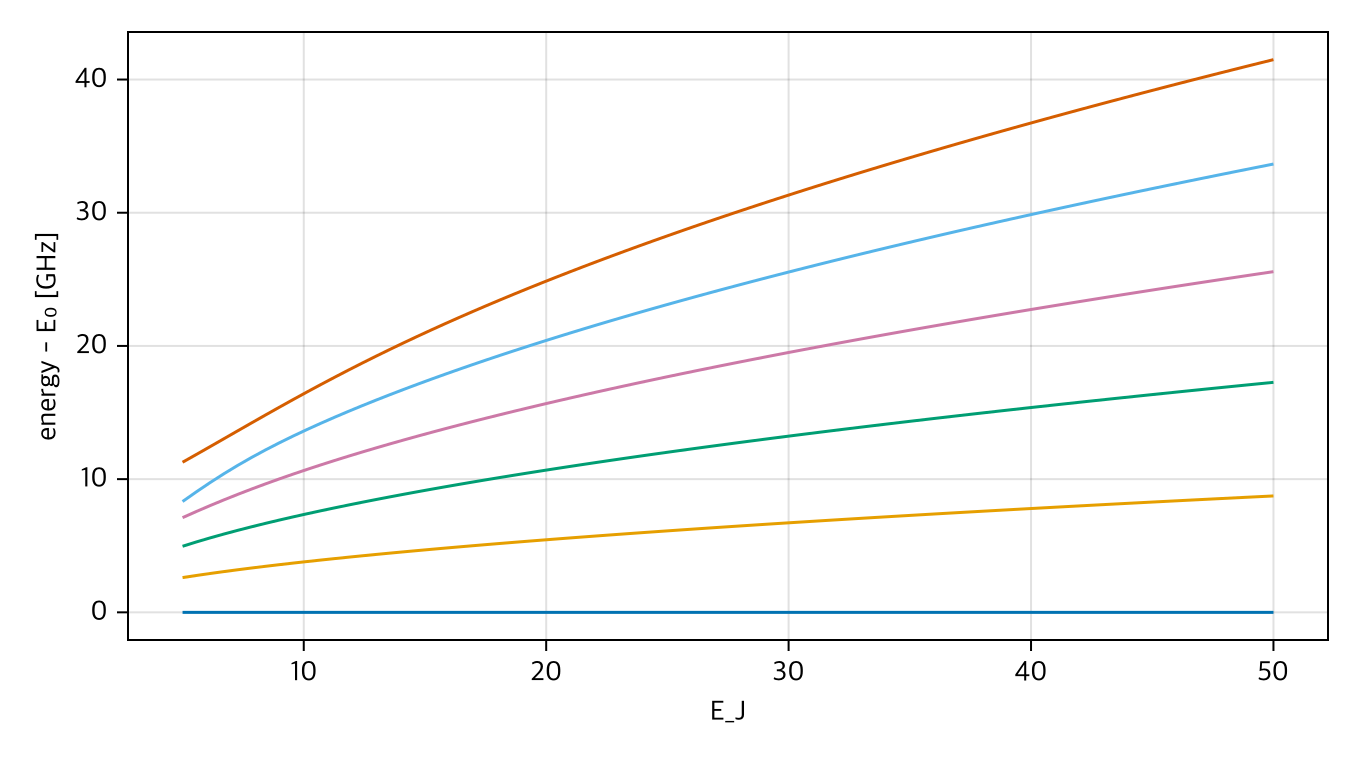

In [9]:
ej_sweep = ParameterSweep(tmon, :EJ, range(5.0, 50.0, length=80); evals_count=6)
plot_evals_vs_paramvals_scqubits(ej_sweep; subtract_ground=true, evals_count=6)


## 6. Charge-basis and phase-basis wavefunctions

In the charge basis, the eigenvectors live on the discrete integer variable `n`, so scqubits visualizes them as a histogram/bar plot rather than a continuous curve.

For phase-basis plots we follow the scqubits convention and reconstruct

$$
\psi_j(\phi)=\frac{i^j}{\sqrt{2\pi}}\sum_n c_n^{(j)} e^{i n \phi}
$$

from the charge-basis coefficients. The gray curve is the cosine potential `-E_J \cos(\phi)`, and each wavefunction is drawn on top of its eigenenergy with scqubits-style adaptive amplitude scaling.



- Currently supported mode : 


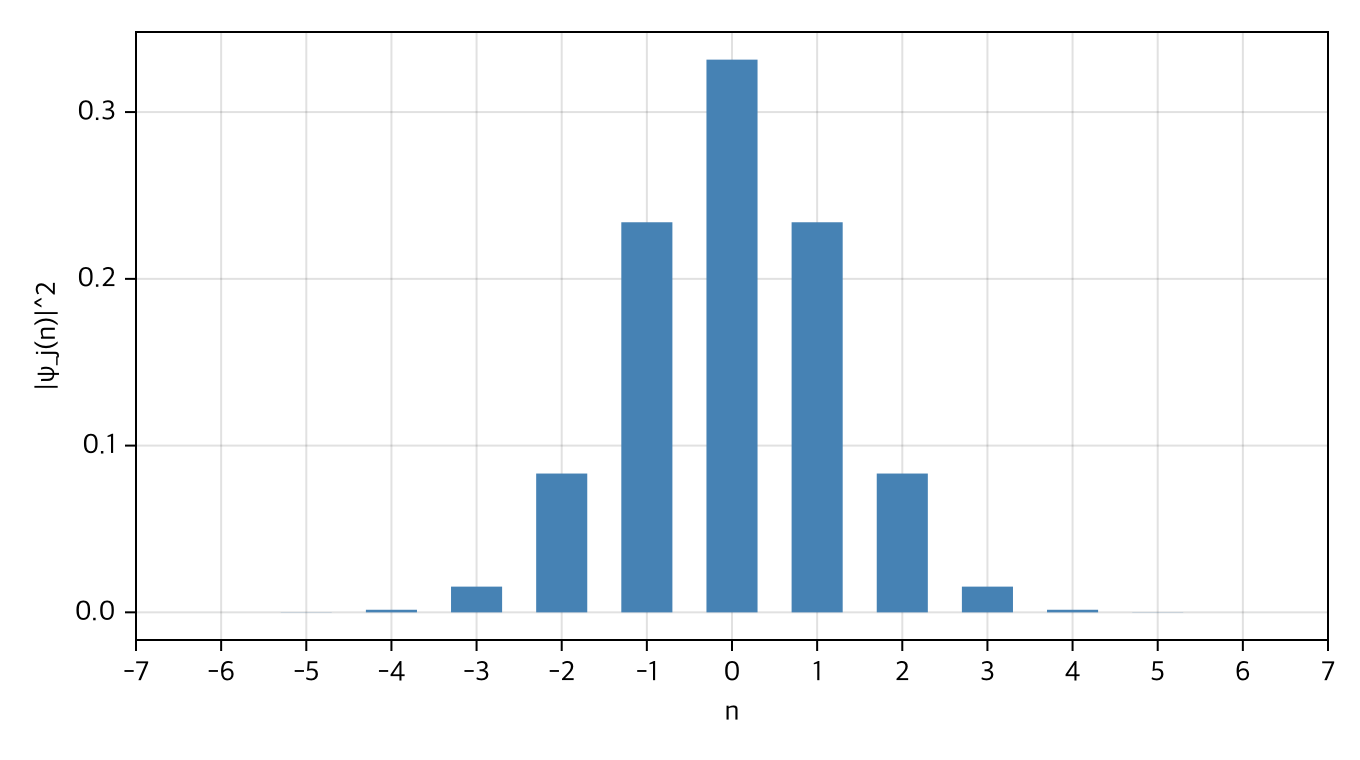

In [10]:
# Charge-basis wavefunction in the discrete number basis
plot_n_wavefunction(tmon; which=0, mode=:abs_sqr, nrange=(-7,7)) #mode:=real & imag 다 확인한뒤 결정해야함


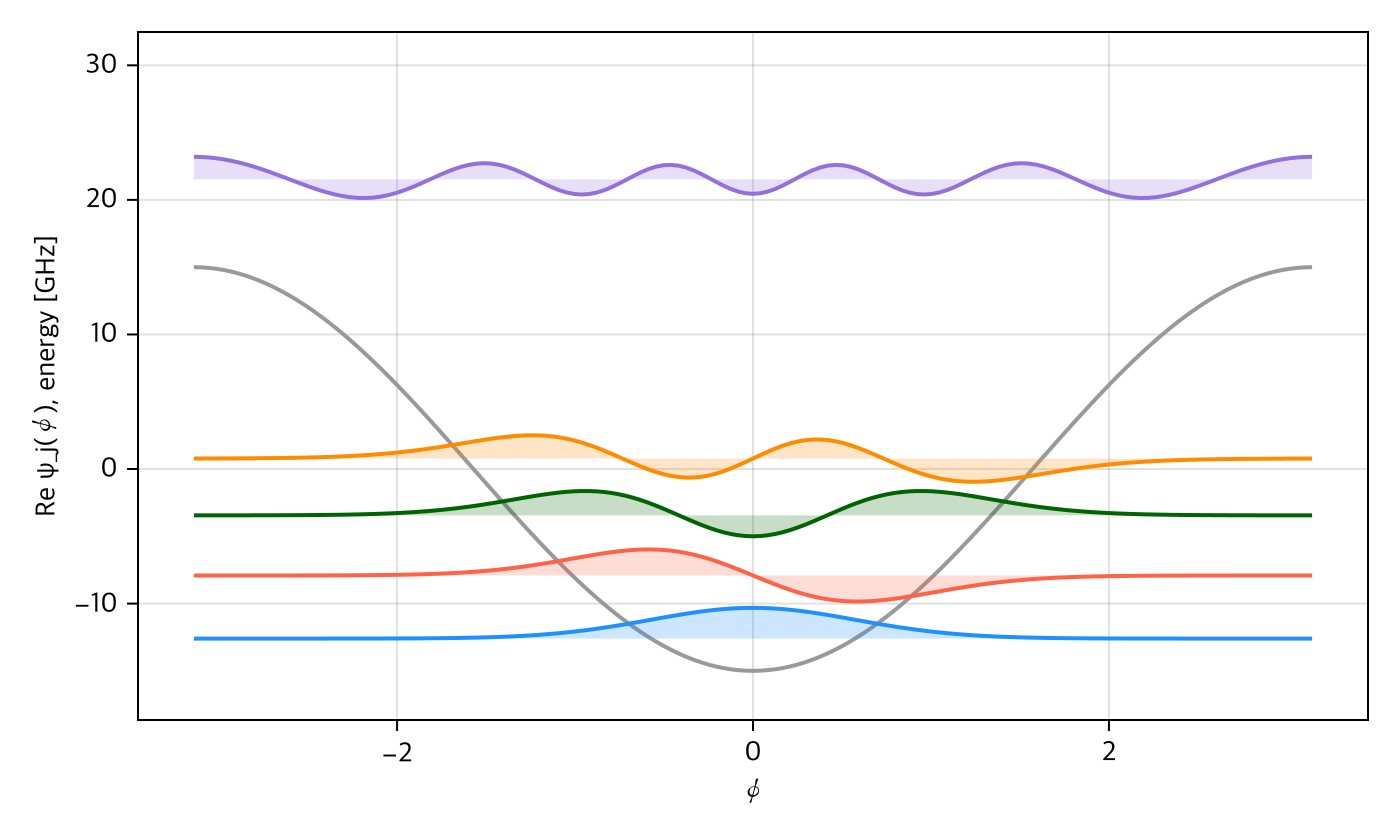

In [11]:
# Phase-basis wavefunctions with the cosine potential and energy offsets
plot_wavefunction(tmon; which=(0, 1, 2, 3, 10), mode=:real)


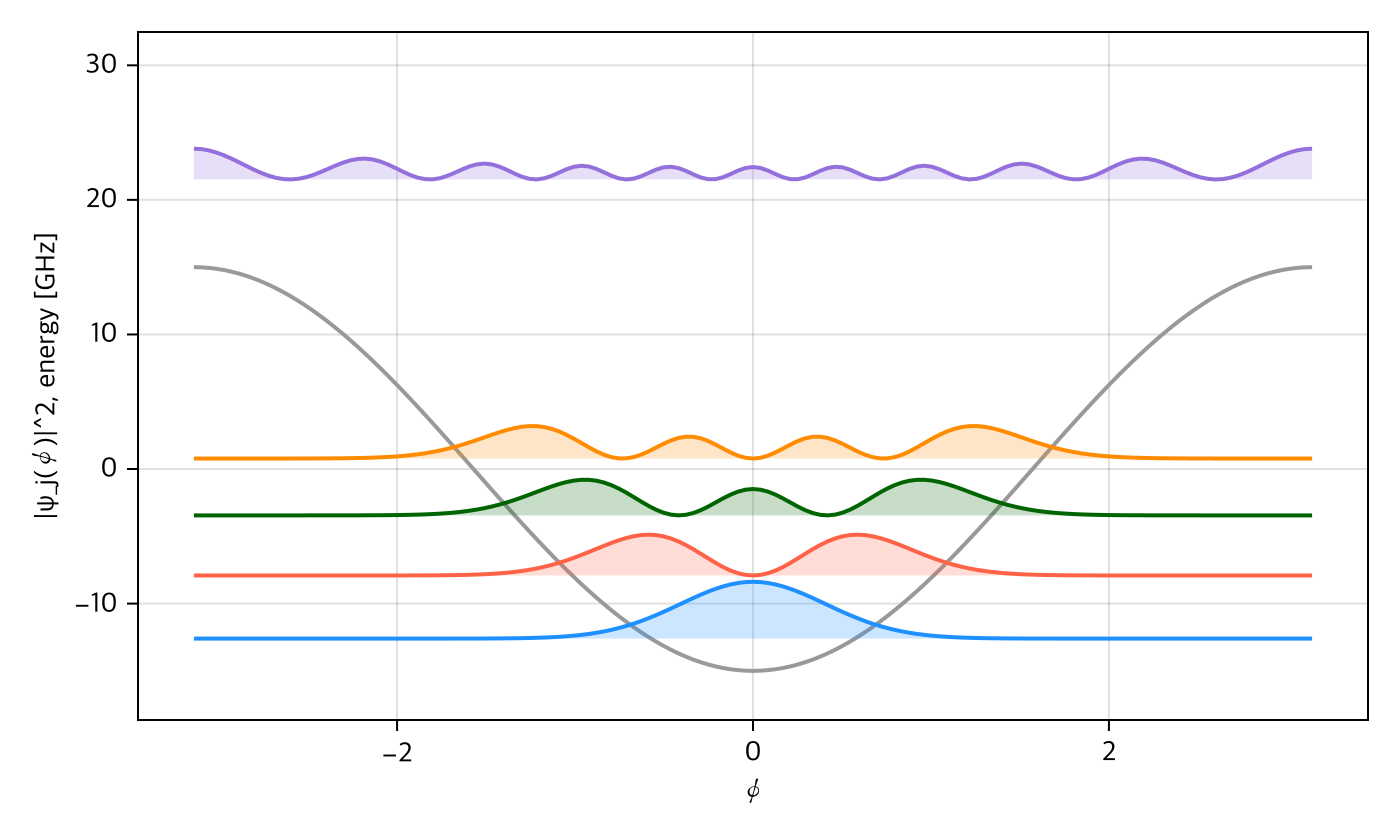

In [12]:
# Phase-basis probability densities
plot_phi_wavefunction(tmon; which=(0, 1, 2,3 ,10), mode=:abs_sqr)


## 7. Charge-dispersion trends vs `EJ`

This section now follows the scqubits `plot_dispersion_vs_paramvals` convention for the transmon example. For charge dispersion, the transmon-specific rule compares spectra only at `n_g = 0.0` and `n_g = 0.5`, then plots the resulting dispersion against the ratio `EJ/EC` on a logarithmic energy-dispersion axis.


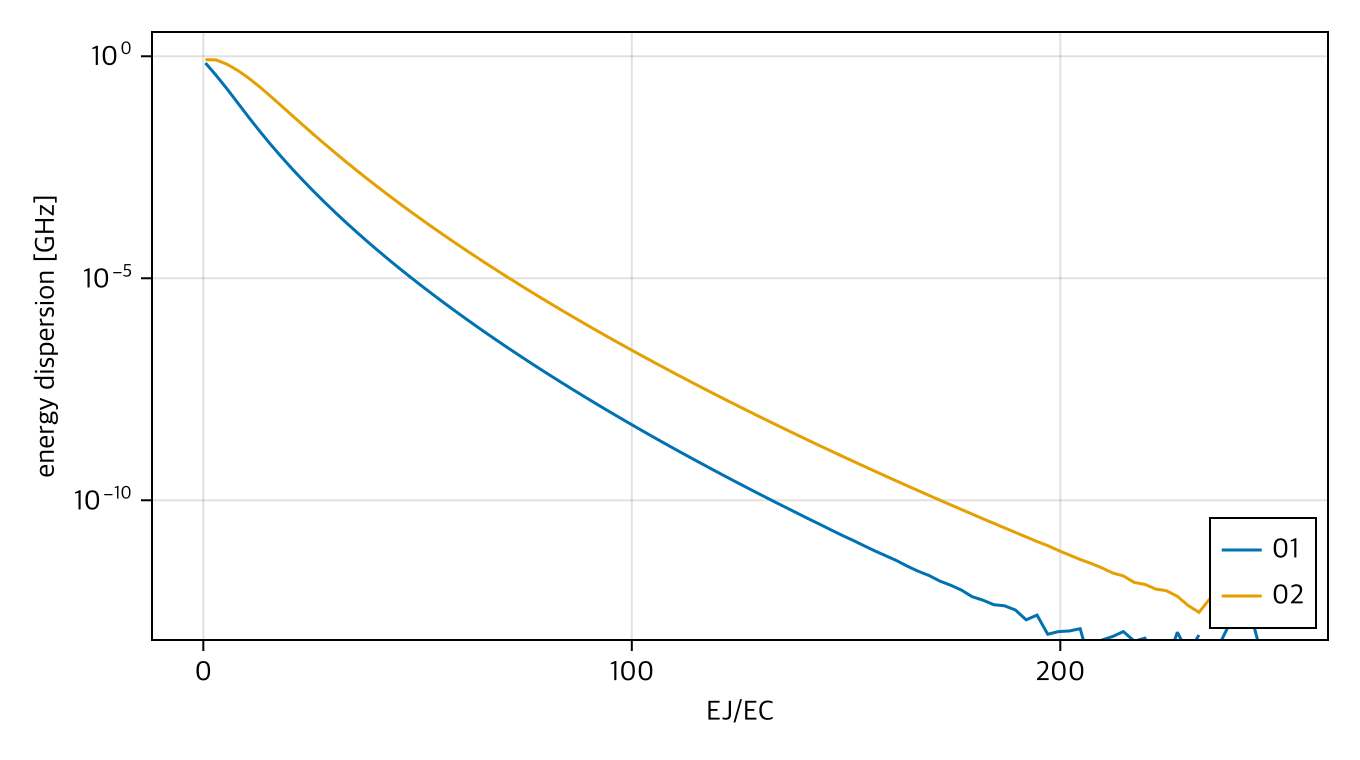

In [13]:
EJvals = range(0.1, 50.0, length=100)
plot_dispersion_vs_paramvals_scqubits(tmon, :ng, :EJ, EJvals; ref_param=:EC, transitions=((0, 1), (0, 2)))


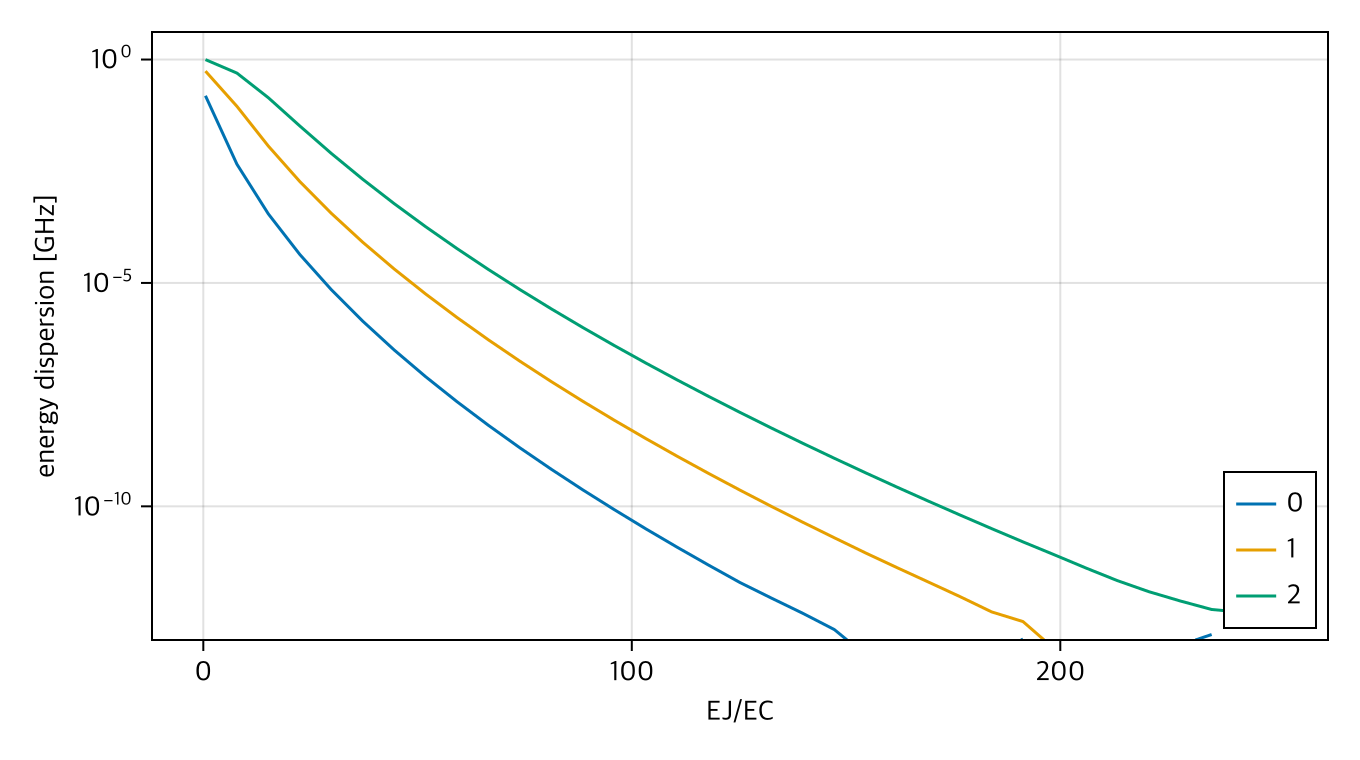

In [14]:
EJvals = range(0.1, 50.0, length=35)
plot_dispersion_vs_paramvals_scqubits(tmon, :ng, :EJ, EJvals; ref_param=:EC, levels=(0, 1, 2))


## 8. Matrix elements

The built-in API already supports matrix element tables and heatmaps. We also add a notebook-local helper for the scqubits-style "matrix elements vs parameter value" workflow.


In [15]:
round.(matrixelement_table(tmon, n_operator(tmon); evals_count=3), digits=6)


3×3 Matrix{ComplexF64}:
     -0.0+0.0im  -1.21043+0.0im       0.0+0.0im
 -1.21043+0.0im      -0.0+0.0im  -1.67018+0.0im
      0.0+0.0im  -1.67018+0.0im       0.0+0.0im

In [ ]:
plot_matrixelements(tmon, s -> n_operator(s); evals_count=10, mode=:abs)


In [ ]:
plot_matrixelements(tmon, s -> cos_phi_operator(s); evals_count=10, mode=:abs)


In [ ]:
tmon_mel = Transmon(EJ=7.0, EC=tmon.EC, ng=0.0, ncut=tmon.ncut, truncated_dim=8)
plot_matelems_vs_paramvals(
    tmon_mel,
    s -> n_operator(s),
    :ng,
    range(-0.5, 0.5, length=101);
    pairs=[(1, 2), (1, 3), (2, 3), (1, 4)],
    mode=:abs,
)


## 9. Circuit-derived validation

A single JJ branch in `Circuit` uses branch charging energy `EC_branch`, with the convention

$$E_{C,\text{total}} = 4E_{C,\text{branch}}$$

for a single junction to ground in this codebase. That lets us check the hard-coded `Transmon` implementation against the general circuit quantization path.


In [ ]:
tmon.EC

In [ ]:
desc = """
branches:
  - [JJ, 0, 1, EJ=15.0, EC=$(tmon.EC / 4)]
"""
circ = Circuit(desc; ncut=tmon.ncut)

evals_circ = eigenvals(circ; evals_count=6)
evals_hard = eigenvals(tmon; evals_count=6)

(
    circuit_evals_GHz=round.(evals_circ, digits=8),
    hardcoded_evals_GHz=round.(evals_hard, digits=8),
    max_abs_difference=maximum(abs.(evals_circ .- evals_hard)),
)
